In [29]:
import torch
import torchvision

print(f"Torch version: {torch.__version__} | Torchvision version: {torchvision.__version__}")

Torch version: 2.11.0+cpu | Torchvision version: 0.26.0+cpu


1. Get and preprocess data

In [ ]:
import kagglehub

raw_path = kagglehub.dataset_download("blourdhuraju/cifar-10")

print("Path to dataset files:", raw_path)

In [ ]:
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "cifar_10"

train_dir = image_path / "train"
val_dir = image_path / "val"
test_dir = image_path / "test"

if not (train_dir.is_dir() and val_dir.is_dir() and test_dir.is_dir()):
  train_dir.mkdir(parents=True, exist_ok=True)
  val_dir.mkdir(parents=True, exist_ok=True)
  test_dir.mkdir(parents=True, exist_ok=True)
  print(f"{train_dir}, {val_dir} and {test_dir} directories are created!")
else:
  print(f"{train_dir}, {val_dir} and {test_dir} are already exists!")

In [ ]:
import os

def walk_through(dir: str):
  for dirpath, dirnames, filenames in os.walk(dir):
    print(f"There are {len(dirnames)} directories and {len(filenames)} files in {dirpath}")

In [ ]:
walk_through(raw_path)

In [ ]:
raw_path = Path(raw_path)
class_names_file = raw_path / "cifar10" / "class_names.txt"

with open(class_names_file, "r") as file:
  class_names = {str(i): item_class.strip() for i, item_class in enumerate(file)}

  print(f"class_idx: {class_names}")

In [ ]:
from shutil import copy
import pathlib
from pathlib import Path

def copy_image_from_raw_to_dest_path(raw_path: pathlib.Path, dest_parent_path: pathlib.Path):
  path_list = list(raw_path.glob("*/*.png"))

  print(f"Copy is still running ...")

  for i, path in enumerate(path_list):
    parent_dir_name = path.parent.stem
    parent_name = class_names[parent_dir_name]

    destination_parent_name = dest_parent_path / parent_name

    destination_parent_name.mkdir(parents=True, exist_ok=True)

    destination_path = destination_parent_name / path.name
    copy(path, destination_path)

  print("Copy is finished!")

In [ ]:
cifar10_path = raw_path / "cifar10"
cifar10_val_path = cifar10_path / "val"
cifar10_train_path = cifar10_path / "train"
cifar10_test_path = cifar10_path / "test"

copy_image_from_raw_to_dest_path(cifar10_train_path, train_dir)
copy_image_from_raw_to_dest_path(cifar10_test_path, test_dir)
copy_image_from_raw_to_dest_path(cifar10_val_path, val_dir)

Copy is still running ...
Copy is finished!
Copy is still running ...


In [ ]:
old_train_path_list = list(cifar10_train_path.glob("*/*.png"))
old_test_path_list = list(cifar10_test_path.glob("*/*.png"))
old_val_path_list = list(cifar10_val_path.glob("*/*.png"))

new_train_path_list = list(train_dir.glob("*/*.png"))
new_test_path_list = list(test_dir.glob("*/*.png"))
new_val_path_list = list(val_dir.glob("*/*.png"))

print(f"Same lenght train: {len(old_train_path_list) == len(new_train_path_list)}")
print(f"Same lenght test: {len(old_test_path_list) == len(new_test_path_list)}")
print(f"Same lenght val: {len(old_val_path_list) == len(new_val_path_list)}")

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

train_path_list = list(train_dir.glob("*/*.png"))
img, label = train_path_list[1], train_path_list[1].parent.stem
transforms_simple = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size=(255, 255)),
    torchvision.transforms.ToTensor()
])

with Image.open(img) as image:
  img_arr = np.array(image)
  tr_image = transforms_simple(image)
  plt.figure(figsize=(12, 8))
  plt.imshow(tr_image.permute(1, 2, 0))
  plt.title(f"Class: {label} | Shape: {tr_image.shape}")
  plt.axis("off")


In [ ]:
import random

random.seed(42)
random_paths = random.choices(train_path_list, k=9)

plt.figure(figsize=(20, 20))

for i, path in enumerate(random_paths):
  with Image.open(path) as image:
    image_arr = np.array(image)
    plt.subplot(3, 3, i+1)
    plt.imshow(image_arr)
    plt.title(f"Label: {path.parent.stem} | Shape: {image_arr.shape}")
    plt.axis("off")


2. Data preparation

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms,
    target_transform=None
)

val_data = datasets.ImageFolder(
    root=val_dir,
    transform=val_transforms,
    target_transform=None
)

class_names, class_to_idx = train_data.classes, train_data.class_to_idx
print(f"Classes: {class_names} | Class_to_idx: {class_to_idx}")
train_data, val_data

In [ ]:
image, label = train_data[0]
plt.figure(figsize=(12, 8))
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Class: {class_names[label]} | Shape: {image.shape}")
plt.axis("off")
plt.show()

In [ ]:
from torch.utils.data import DataLoader
import os

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)

val_dataloader = DataLoader(
    dataset=val_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)

train_dataloader, val_dataloader

In [ ]:
sample = next(iter(train_dataloader))
sample_img, sample_label = sample
sample_img[0], sample_label[0]

In [ ]:
import os
from typing import Tuple, List, Dict

def get_classes(path: str) -> Tuple[List[str], Dict[int, str]]:
  classes = sorted([entry.name for entry in os.scandir(path)])
  class_to_idx = {entry: i for i, entry in enumerate(classes)}

  return classes, class_to_idx

In [ ]:
classes, class_to_idx = get_classes(train_dir)
print(classes)
print(class_to_idx)

In [ ]:
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from typing import Tuple, List, Dict

class CustomImageDataset(Dataset):
  def __init__(self, tag_dir: str, transforms):
    super().__init__()
    self.paths = list(Path(tag_dir).glob("*/*.png"))
    self.transforms = transforms
    self.classes, self.class_to_idx = get_classes(tag_dir)

  def __len__(self):
    return len(self.paths)

  def __getitem__(self, index):
    image = self.paths[index]

    with Image.open(image) as img:
      if self.transforms:
        image_transformed = self.transforms(img)
      else:
        image_transformed = img
      label = self.class_to_idx[image.parent.stem]

    return image_transformed, label

In [ ]:
custom_train_data = CustomImageDataset(tag_dir=train_dir, transforms=train_transforms)
img, label = custom_train_data[0]
print(f"Image: {img}")
print(f"Label: {label}")

3. Build model

In [ ]:
from torch import nn

class TinyVGG(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(
            in_channels=input_shape,
            out_channels=hidden_units,
            kernel_size=3,
            padding=1,
            stride=1
        ),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            padding=1,
            stride=1
        ),
        nn.MaxPool2d(
            kernel_size=3
        )
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            padding=1,
            stride=1
        ),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            padding=1,
            stride=1
        ),
        nn.MaxPool2d(
            kernel_size=3
        )
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units * 3 * 3, out_features=output_shape)
    )

  def forward(self, x) -> torch.Tensor:
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)

    return x


In [ ]:
torch.manual_seed(42)

model_V0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data.classes))

try:
  from torchinfo import summary
except:
  !pip install torchinfo
  from torchinfo import summary


summary(model_V0)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

4. Training loop

In [ ]:
def train_step(model: nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: nn.Module, optimizer: torch.optim.Optimizer,
               device: torch.device=device):

  model = model.to(device)
  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_logit = model(X)
    loss = loss_fn(y_logit, y)
    train_loss += loss.item()
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
    train_acc += (torch.eq(y_pred, y).sum().item() / len(y_pred))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc

In [ ]:
def test_step(model: nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: nn.Module,
              device: torch.device=device):

  model.to(device)
  test_loss, test_acc = 0, 0
  model.eval()

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      y_logit = model(X)
      loss = loss_fn(y_logit, y)
      test_loss += loss.item()
      y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
      test_acc += (torch.eq(y_pred, y).sum().item() / len(y_pred))

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc

In [ ]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

def train(model: nn.Module, train_dataloader: torch.utils.data.DataLoader, test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer, loss_fn: nn.Module=nn.CrossEntropyLoss(), epochs: int = 5, device: torch.device=device):

  results = {
      "train_loss": [],
      "test_loss": [],
      "train_acc": [],
      "test_acc": []
  }

  start_time = timer()

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
    test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)

    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    print(f"Epoch {epoch + 1}:")
    print(f"Train loss: {train_loss: .3f} | Test loss: {test_loss: .3f}")
    print(f"Train acc: {train_acc: .3f} | Test acc: {test_acc: .3f}\n")

  end_time = timer()
  total_training_time = end_time - start_time
  print(f"Training time: {total_training_time: .3f} seconds")

  return results

In [ ]:
adam_optimizer = torch.optim.Adam(params=model_V0.parameters(), lr=0.01)
sgd_optimizer = torch.optim.SGD(params=model_V0.parameters(), lr=0.01)
EPOCHS = 10

train_results = train(model_V0, train_dataloader, val_dataloader, sgd_optimizer,
                      epochs=EPOCHS, device=device)

In [30]:
import pandas as pd

df_results = pd.DataFrame(train_results)
df_results

,train_loss,test_loss,train_acc,test_acc
0,2.275650,2.100734,0.136771,0.262142
1,2.124890,1.901325,0.230144,0.332803
2,1.999994,1.837050,0.288069,0.338177
3,1.912092,1.672897,0.321651,0.408838
4,1.861068,1.580576,0.339530,0.439689
5,1.820123,1.615897,0.353834,0.419188
6,1.777622,1.526101,0.373201,0.453225
7,1.749212,1.461714,0.385261,0.485072
8,1.729235,1.411759,0.396811,0.515127
9,1.706917,1.369914,0.403563,0.527070


[]

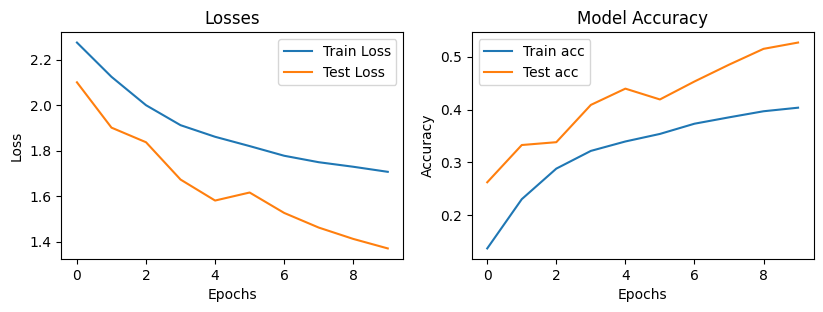

In [40]:
import matplotlib.pyplot as plt

epochs = range(len(df_results["train_loss"]))

plt.figure(figsize=(15, 10))
plt.subplot(3, 3, 1)
plt.plot(epochs, df_results["train_loss"], label="Train Loss")
plt.plot(epochs, df_results["test_loss"], label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Losses")
plt.legend()

plt.subplot(3, 3, 2)
plt.plot(epochs, df_results["train_acc"], label="Train acc")
plt.plot(epochs, df_results["test_acc"], label="Test acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

# plt.suplot(3, 3, 2)
# plt.plot(EPOCHS, df_results["test_acc"])
# plt.xlabel("Epochs")
# plt.ylable("Accuracy")
# plt.title("Test acc")

# plt.subplot(3, 3, 2)
# plt.plot(epochs, df_results["test_loss"])
# plt.xlabel("Epochs")
# plt.ylabel("Loss")
# plt.title("Test loss")

plt.plot()

5. Inference

In [50]:
import torchvision

test_path_list = list(test_dir.glob("*/*.png"))
test_image = test_path_list[0]

class_name = test_image.parent.stem
test_image = torchvision.io.read_image(test_image)
print(f"Shape: {test_image.shape}")
print(f"Image: {test_image}")
print(f"Class: {class_name}")


Shape: torch.Size([3, 32, 32])
Image: tensor([[[255, 254, 254,  ..., 113, 111,  95],
         [255, 252, 252,  ..., 106,  98,  75],
         [255, 252, 252,  ..., 101,  92,  78],
         ...,
         [255, 255, 255,  ...,  56,  69,  90],
         [255, 255, 255,  ...,  88,  99, 119],
         [255, 255, 255,  ..., 135, 137, 132]],

        [[254, 252, 252,  ..., 137, 135, 116],
         [253, 250, 250,  ..., 132, 124,  96],
         [254, 250, 250,  ..., 127, 118,  99],
         ...,
         [252, 250, 250,  ...,  58,  70,  87],
         [252, 250, 250,  ...,  83,  94, 112],
         [252, 250, 250,  ..., 122, 123, 119]],

        [[255, 255, 255,  ..., 103, 101,  88],
         [255, 253, 253,  ...,  85,  80,  65],
         [255, 252, 252,  ...,  77,  73,  68],
         ...,
         [255, 254, 254,  ...,  38,  55,  91],
         [255, 254, 254,  ...,  92, 101, 120],
         [255, 253, 254,  ..., 136, 133, 125]]], dtype=torch.uint8)
Class: automobile


In [45]:
test_image = test_image / 255
print(test_image)

tensor([[[1.0000, 0.9961, 0.9961,  ..., 0.4431, 0.4353, 0.3725],
         [1.0000, 0.9882, 0.9882,  ..., 0.4157, 0.3843, 0.2941],
         [1.0000, 0.9882, 0.9882,  ..., 0.3961, 0.3608, 0.3059],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 0.2196, 0.2706, 0.3529],
         [1.0000, 1.0000, 1.0000,  ..., 0.3451, 0.3882, 0.4667],
         [1.0000, 1.0000, 1.0000,  ..., 0.5294, 0.5373, 0.5176]],

        [[0.9961, 0.9882, 0.9882,  ..., 0.5373, 0.5294, 0.4549],
         [0.9922, 0.9804, 0.9804,  ..., 0.5176, 0.4863, 0.3765],
         [0.9961, 0.9804, 0.9804,  ..., 0.4980, 0.4627, 0.3882],
         ...,
         [0.9882, 0.9804, 0.9804,  ..., 0.2275, 0.2745, 0.3412],
         [0.9882, 0.9804, 0.9804,  ..., 0.3255, 0.3686, 0.4392],
         [0.9882, 0.9804, 0.9804,  ..., 0.4784, 0.4824, 0.4667]],

        [[1.0000, 1.0000, 1.0000,  ..., 0.4039, 0.3961, 0.3451],
         [1.0000, 0.9922, 0.9922,  ..., 0.3333, 0.3137, 0.2549],
         [1.0000, 0.9882, 0.9882,  ..., 0.3020, 0.2863, 0.

In [51]:
test_image.device

device(type='cpu')

In [57]:
import torchvision
import torch
from pathlib import Path

def make_prediction(model: nn.Module, image_path: str, transforms: None, class_names: List[str], device:torch.device=device):
  model = model.to(device)

  image_path = Path(image_path)
  readed_image = torchvision.io.read_image(image_path)
  readed_image = readed_image / 255
  readed_image = readed_image.to(device)

  if transforms:
    readed_image = transforms(readed_image)

  with torch.inference_mode():
    readed_image = torch.unsqueeze(readed_image, dim=0)
    y_logit = model(readed_image)
    y_pred_probs = torch.softmax(y_logit, dim=1)
    y_pred = torch.argmax(y_pred_probs, dim=1)
    y_pred_prob = y_pred_probs.cpu().max().item()
    class_pred = class_names[y_pred]

    return y_pred_prob, class_pred

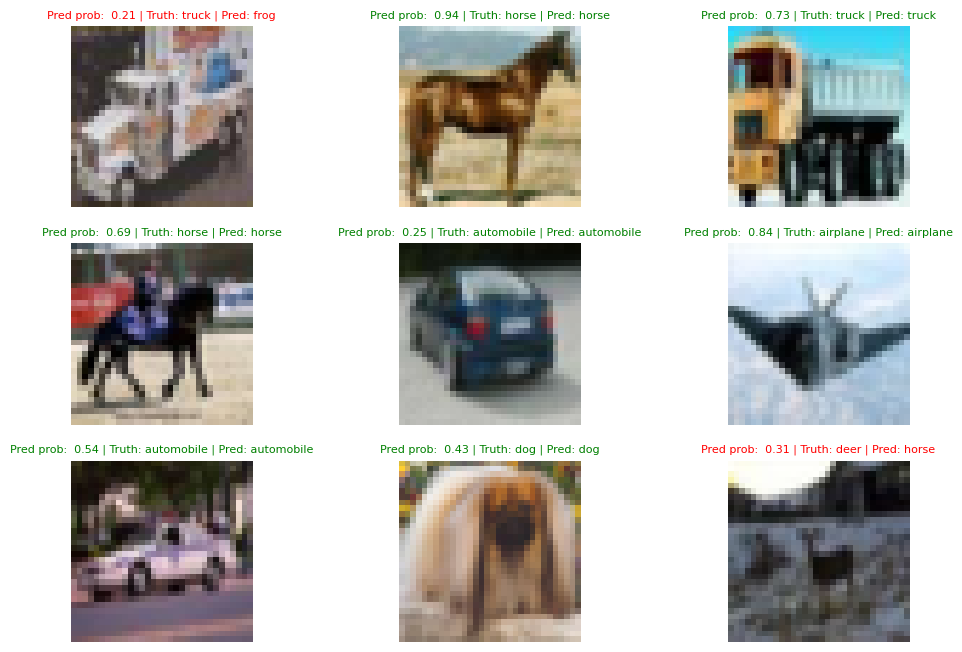

In [73]:
import random
import numpy as np

test_path_list = list(test_dir.glob("*/*.png"))
class_names = train_data.classes

random_paths = random.choices(test_path_list, k=9)

plt.figure(figsize=(12, 8))

for i, path in enumerate(random_paths):
  with Image.open(path) as image:
    truth_class = path.parent.stem
    prob_pred, pred_class = make_prediction(model=model_V0, image_path=path, class_names=class_names, device=device, transforms=None)
    plt.subplot(3, 3, i+1)
    plt.imshow(np.array(image))
    plt.title(f"Pred prob: {prob_pred: .2f} | Truth: {truth_class} | Pred: {pred_class}", color="green" if truth_class == pred_class else "red", fontsize=8)
    plt.axis("off")
    plt.plot()